# Student Performance Indicator
### Machine Learning Model Application on Student Performance

**Life cycle of this Machine Learning Project**
1. Understanding the Problem Statement
2. Data Collection
3. Data Checks to perform
4. Exploratory Data Analysis (EDA)
5. Data Pre-Processing
6. Model Training
7. Choose the Best Model


## 1) Problem Statement

This project understands how a student's performance (test scores) is affected by
other variables such as **Gender, Ethnicity (Race/Group), Parental level of education,
Lunch type, and Test preparation course**.

**Goal:** Build and compare regression models that predict a student's **Math Score**
from the other available features (reading score, writing score, and the demographic /
categorical variables above), then select the best-performing model.


## 2) Data Collection

**Dataset Source:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977

The data consists of 8 columns and 1000 rows:
- gender
- race/ethnicity
- parental level of education
- lunch
- test preparation course
- math score
- reading score
- writing score


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('StudentsPerformance_3_lyst1729690388778.csv')
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
print("Shape of the dataset:", df.shape)
df.info()


Shape of the dataset: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## 3) Data Checks to Perform

- Check missing values
- Check duplicates
- Check data types
- Check number of unique values in each column
- Check statistics of the dataset
- Check various categories present in the different categorical columns


In [3]:
# Check for missing values
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [4]:
# Check for duplicates
print("Number of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [5]:
# Check data types
df.dtypes


gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

In [6]:
# Check number of unique values of each column
df.nunique()


gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [7]:
# Check statistics of the dataset
df.describe()


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [8]:
print("Categories in 'gender' variable:      ", df['gender'].unique())
print("Categories in 'race/ethnicity' variable:  ", df['race/ethnicity'].unique())
print("Categories in 'parental level of education' variable:", df['parental level of education'].unique())
print("Categories in 'lunch' variable:      ", df['lunch'].unique())
print("Categories in 'test preparation course' variable: ", df['test preparation course'].unique())


Categories in 'gender' variable:       ['female' 'male']
Categories in 'race/ethnicity' variable:   ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable:       ['standard' 'free/reduced']
Categories in 'test preparation course' variable:  ['none' 'completed']


In [9]:
# Define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('We have {} categorical features : {}'.format(len(categorical_features), categorical_features))


We have 3 numerical features : ['math score', 'reading score', 'writing score']
We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [10]:
# Adding two new columns: total_score and average
df['total_score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total_score'] / 3
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


## 4) Exploratory Data Analysis (EDA)

### 4.1 Distribution of the target variable (Math Score)

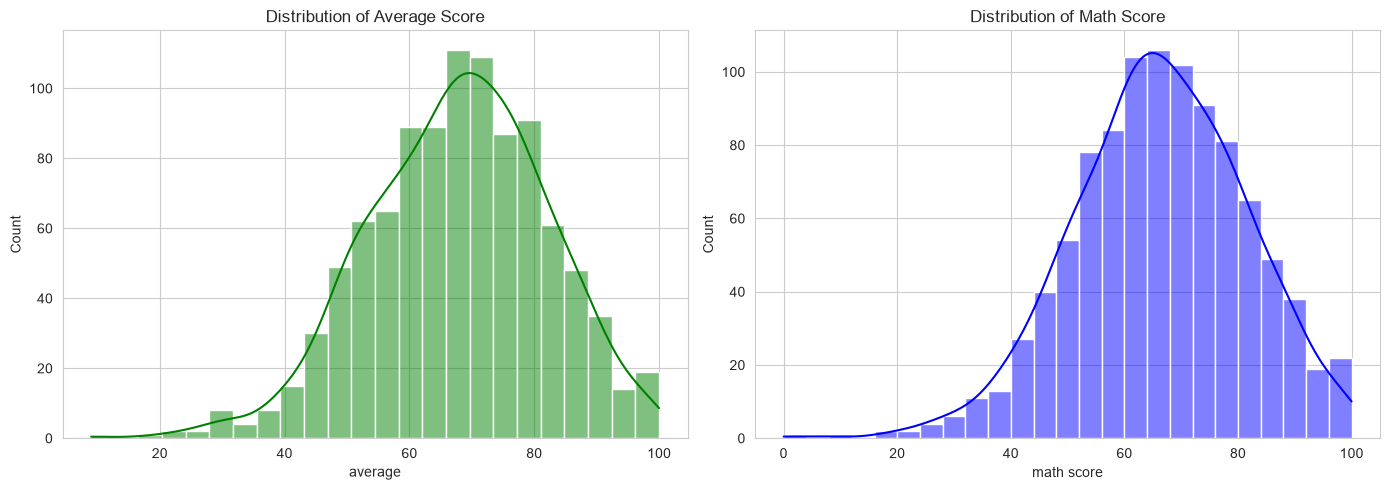

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='average', kde=True, ax=axs[0], color='g')
axs[0].set_title('Distribution of Average Score')
sns.histplot(data=df, x='math score', kde=True, ax=axs[1], color='b')
axs[1].set_title('Distribution of Math Score')
plt.tight_layout()
plt.show()


### 4.2 Effect of gender on scores

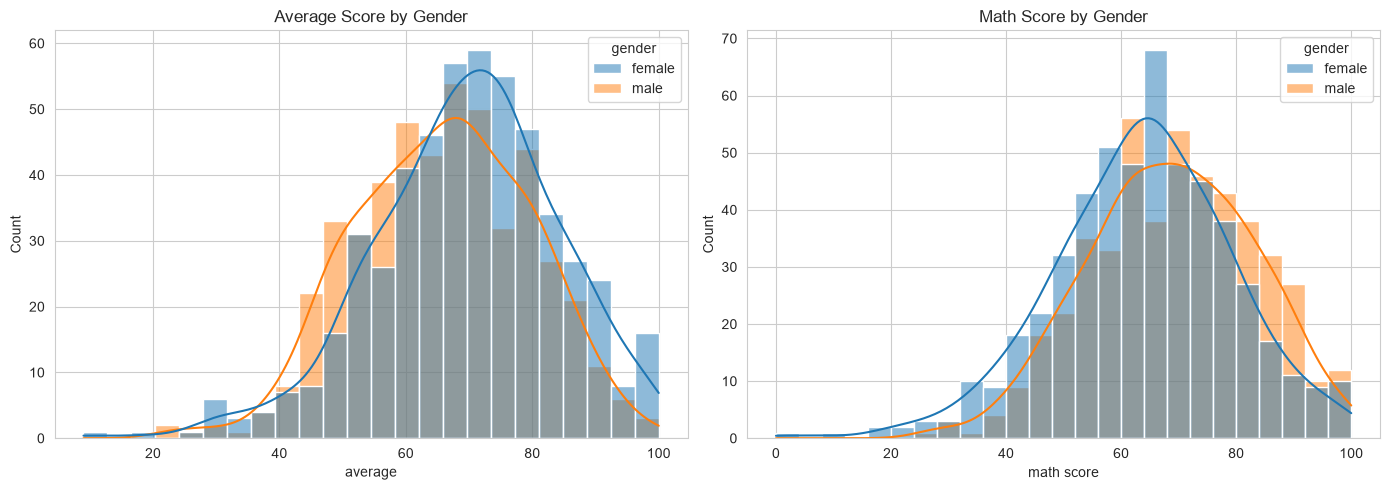

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='average', kde=True, hue='gender', ax=axs[0])
axs[0].set_title('Average Score by Gender')
sns.histplot(data=df, x='math score', kde=True, hue='gender', ax=axs[1])
axs[1].set_title('Math Score by Gender')
plt.tight_layout()
plt.show()


### 4.3 Effect of parental level of education, lunch, and test preparation

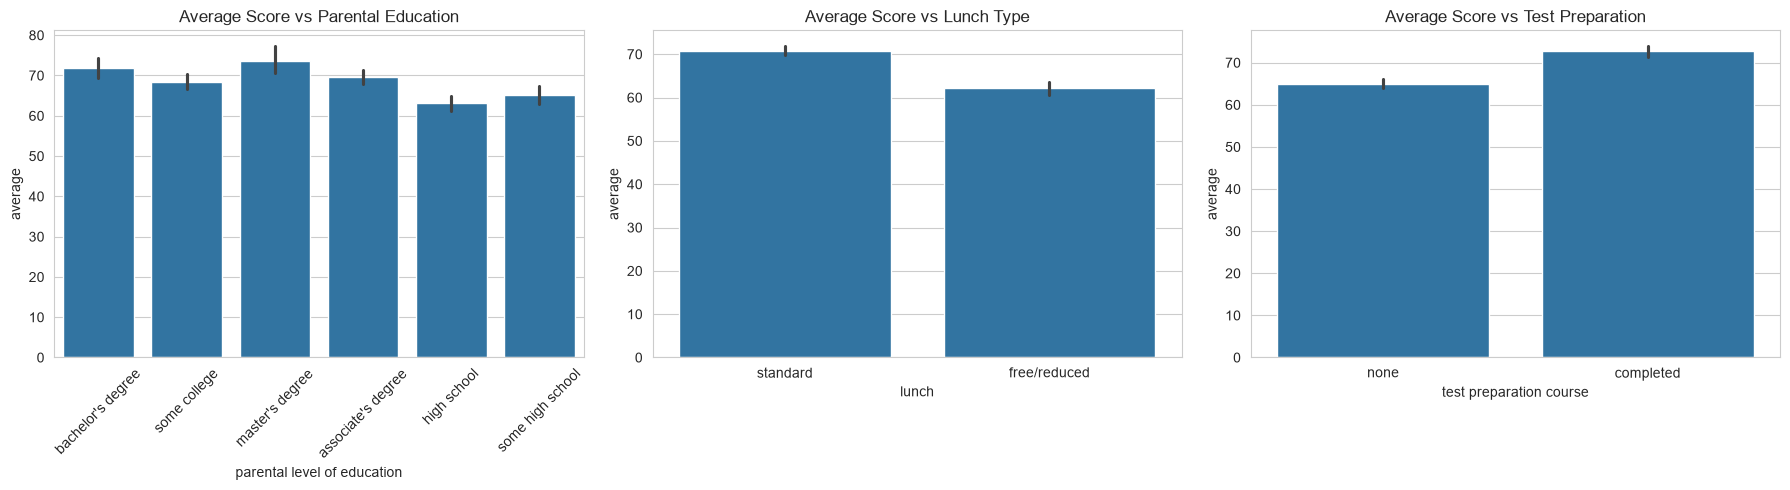

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(x='parental level of education', y='average', data=df, ax=axs[0])
axs[0].set_title('Average Score vs Parental Education')
axs[0].tick_params(axis='x', rotation=45)

sns.barplot(x='lunch', y='average', data=df, ax=axs[1])
axs[1].set_title('Average Score vs Lunch Type')

sns.barplot(x='test preparation course', y='average', data=df, ax=axs[2])
axs[2].set_title('Average Score vs Test Preparation')
plt.tight_layout()
plt.show()


### 4.4 Effect of race/ethnicity

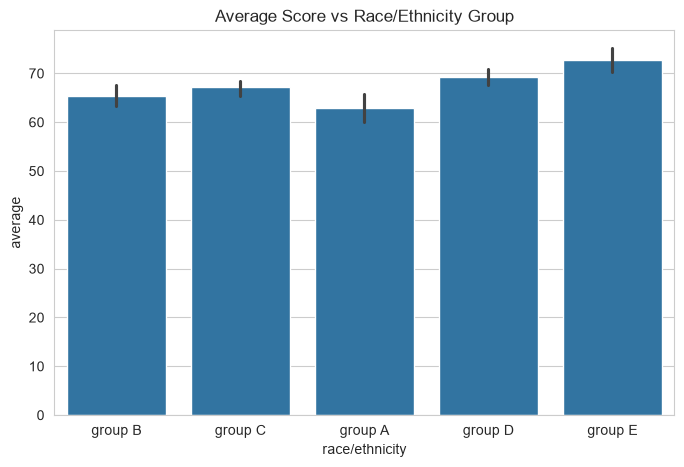

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x='race/ethnicity', y='average', data=df)
plt.title('Average Score vs Race/Ethnicity Group')
plt.show()


### 4.5 Correlation between numeric scores

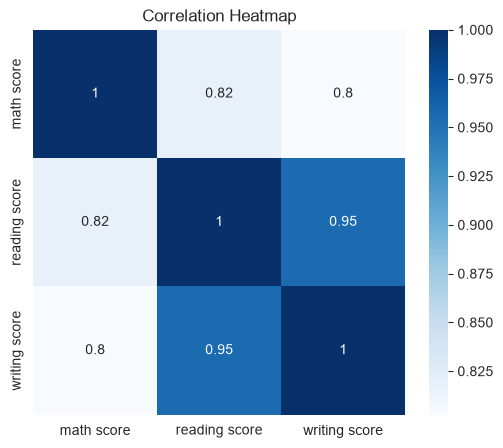

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()


**EDA Insights:**
- Reading and writing scores are strongly correlated with math score, so they will be
  strong predictors.
- Completing the test preparation course is associated with higher average scores.
- Students with the 'standard' lunch tend to score higher than 'free/reduced' lunch.
- Parental level of education shows a mild positive relationship with scores — students
  whose parents hold a master's/bachelor's degree tend to score somewhat higher.


## 5) Data Pre-Processing

We will predict **math score** using the remaining features:
- Numerical: reading score, writing score
- Categorical: gender, race/ethnicity, parental level of education, lunch, test preparation course

Categorical features are one-hot encoded and numerical features are standardized,
using a `ColumnTransformer` inside a modeling pipeline to avoid data leakage.


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df.drop(columns=['math score', 'total_score', 'average'])
y = df['math score']

num_features = ['reading score', 'writing score']
cat_features = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first'), cat_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (800, 7)  Test shape: (200, 7)


## 6) Model Training

We train and compare several regression algorithms using the same preprocessing
pipeline, then evaluate each on RMSE, MAE, and R² score.


In [17]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mse)
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    train_mae, train_rmse, train_r2 = evaluate_model(y_train, y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_model(y_test, y_test_pred)

    results.append({
        'Model': name,
        'Train RMSE': train_rmse, 'Train MAE': train_mae, 'Train R2': train_r2,
        'Test RMSE': test_rmse, 'Test MAE': test_mae, 'Test R2': test_r2
    })

results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False).reset_index(drop=True)
results_df


,Model,Train RMSE,Train MAE,Train R2,Test RMSE,Test MAE,Test R2
0,Ridge,5.323498,4.265009,0.874296,5.393615,4.212527,0.880450
1,Linear Regression,5.323051,4.266712,0.874317,5.393994,4.214763,0.880433
2,Random Forest Regressor,2.324437,1.848775,0.976034,6.050442,4.732893,0.849560
3,AdaBoost Regressor,5.735566,4.687310,0.854083,6.162904,4.825347,0.843915
4,Lasso,6.592500,5.205260,0.807223,6.517328,5.155701,0.825447
5,XGBRegressor,1.050947,0.710088,0.995101,6.601225,5.131189,0.820924
6,K-Neighbors Regressor,5.571930,4.459500,0.862290,7.362106,5.705000,0.777262
7,Decision Tree,0.279508,0.018750,0.999653,8.389875,6.670000,0.710732


### 6.1 Visual comparison of model performance (Test R²)

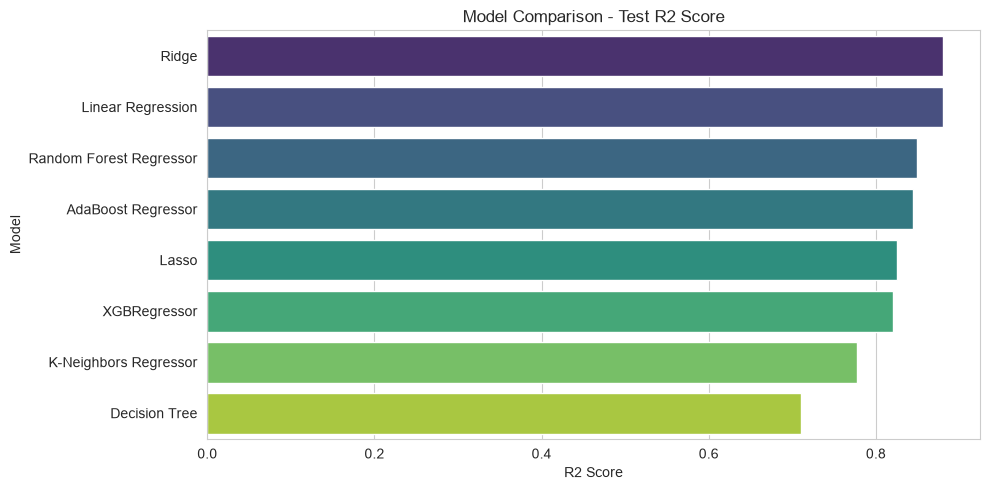

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Test R2', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison - Test R2 Score')
plt.xlabel('R2 Score')
plt.tight_layout()
plt.show()


## 7) Choose the Best Model

In [19]:
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['Test R2']
print(f"Best Model: {best_model_name}")
print(f"Test R2 Score: {best_r2:.4f}")
results_df


Best Model: Ridge
Test R2 Score: 0.8805


,Model,Train RMSE,Train MAE,Train R2,Test RMSE,Test MAE,Test R2
0,Ridge,5.323498,4.265009,0.874296,5.393615,4.212527,0.880450
1,Linear Regression,5.323051,4.266712,0.874317,5.393994,4.214763,0.880433
2,Random Forest Regressor,2.324437,1.848775,0.976034,6.050442,4.732893,0.849560
3,AdaBoost Regressor,5.735566,4.687310,0.854083,6.162904,4.825347,0.843915
4,Lasso,6.592500,5.205260,0.807223,6.517328,5.155701,0.825447
5,XGBRegressor,1.050947,0.710088,0.995101,6.601225,5.131189,0.820924
6,K-Neighbors Regressor,5.571930,4.459500,0.862290,7.362106,5.705000,0.777262
7,Decision Tree,0.279508,0.018750,0.999653,8.389875,6.670000,0.710732


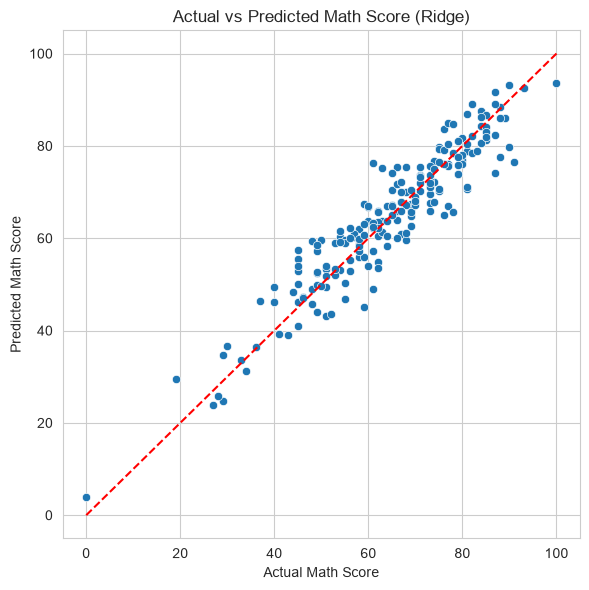

In [20]:
best_model = models[best_model_name]
best_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', best_model)])
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Math Score')
plt.ylabel('Predicted Math Score')
plt.title(f'Actual vs Predicted Math Score ({best_model_name})')
plt.tight_layout()
plt.show()


## Conclusion

- The `results_df` table above ranks every model by test-set R², RMSE, and MAE.
- The **best performing model** is printed above and is the one with the highest
  Test R² (best generalization to unseen data) and lowest Test RMSE/MAE.
- Reading score and writing score are the dominant predictors of math score; the
  categorical demographic features add smaller, incremental improvements.
- This pipeline (preprocessing + model) can be saved with `pickle`/`joblib` and reused
  to predict a new student's math score given their other scores and background info.
